In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("data/OnlineRetail.csv", encoding="ISO-8859-1")

FileNotFoundError: [Errno 2] No such file or directory: '../data/OnlineRetail.csv'

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
df.shape

(541909, 8)

In [7]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df = df.dropna(subset=['CustomerID'])

In [10]:
df.shape

(406829, 8)

In [15]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [16]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [17]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [18]:
df['TotalPrice'].describe()

count    397924.000000
mean         22.394749
std         309.055588
min           0.000000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: TotalPrice, dtype: float64

In [19]:
df.shape

(397924, 9)

In [20]:
df['Country'].nunique()

37

In [25]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
country_sales.head(10)

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: TotalPrice, dtype: float64

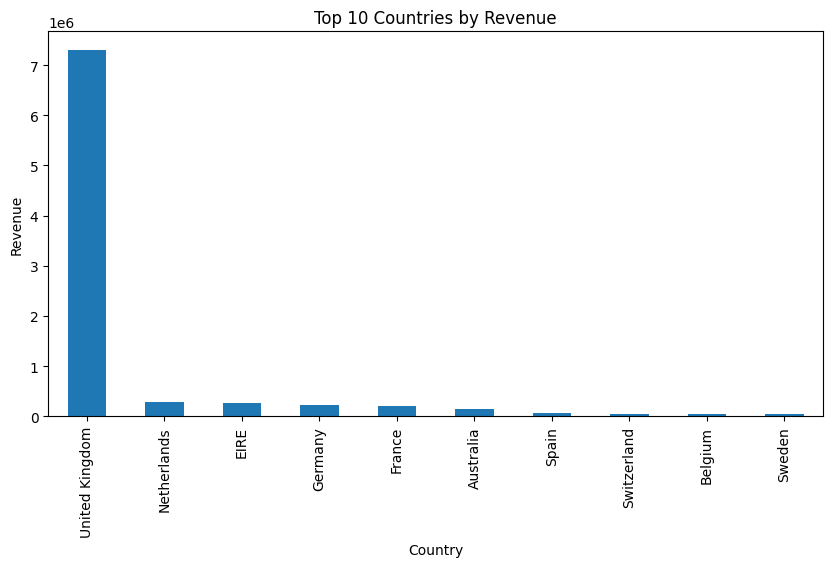

In [26]:
plt.figure(figsize=(10,5))
country_sales.head(10).plot(kind='bar')
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show() 

In [27]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
top_products.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

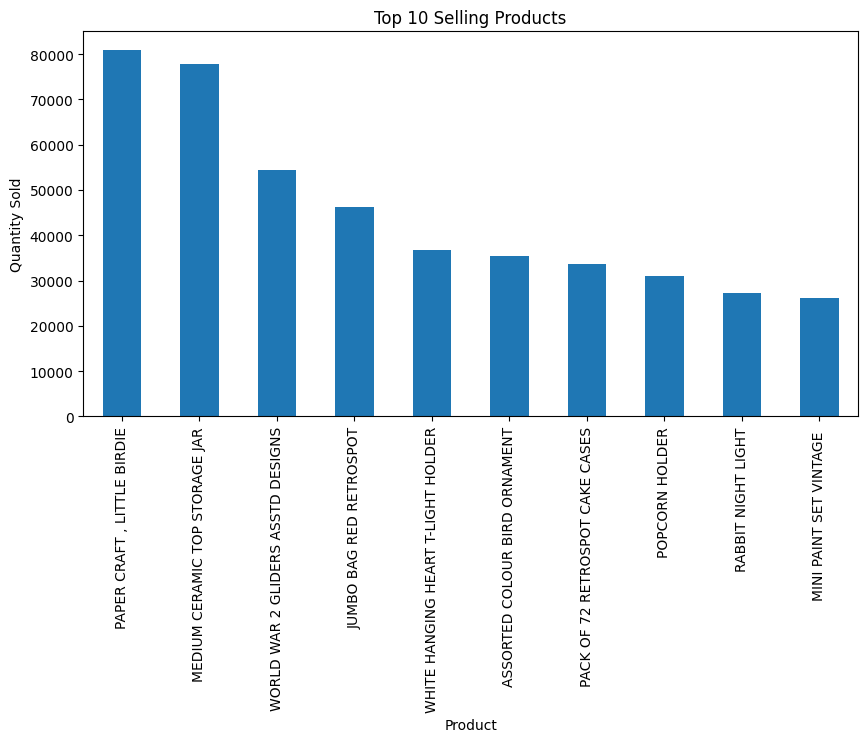

In [28]:
plt.figure(figsize=(10,5))
top_products.head(10).plot(kind='bar')
plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.show()

In [29]:
df['TotalPrice'].sum()

8911407.904

In [30]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [31]:
latest_date = df['InvoiceDate'].max()
latest_date

Timestamp('2011-12-09 12:50:00')

In [32]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})

In [33]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,182,4310.00
12348.0,74,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40


In [34]:
rfm.shape

(4339, 3)

In [35]:
rfm.shape

(4339, 3)

In [39]:
rfm.describe()

,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000
mean,91.518322,91.708689,2053.793018
std,100.009747,228.792852,8988.248381
min,0.000000,1.000000,0.000000
25%,17.000000,17.000000,307.245000
50%,50.000000,41.000000,674.450000
75%,141.000000,100.000000,1661.640000
max,373.000000,7847.000000,280206.020000


In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [41]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [42]:
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency','Frequency','Monetary'])
rfm_scaled.head()

,Recency,Frequency,Monetary
0,2.334858,-0.396512,8.359634
1,-0.905199,0.394688,0.251046
2,-0.175186,-0.265374,-0.028546
3,-0.735196,-0.081781,-0.032963
4,2.174855,-0.326572,-0.191315


In [43]:
inertia = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

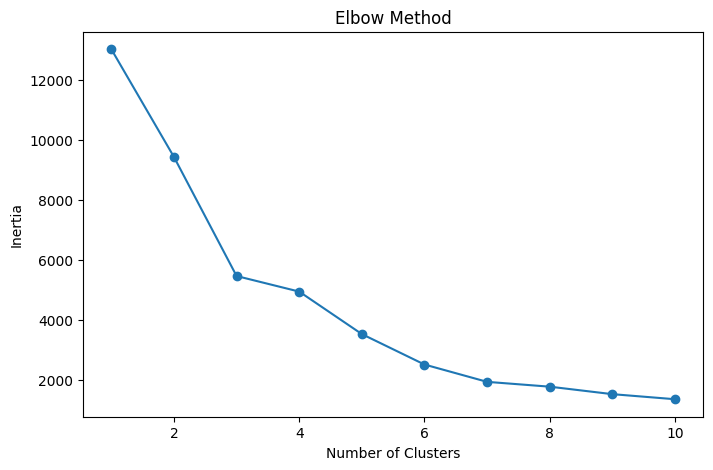

In [44]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [46]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [47]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,325,1,77183.60,3
12347.0,1,182,4310.00,0
12348.0,74,31,1797.24,1
12349.0,18,73,1757.55,0
12350.0,309,17,334.40,3


In [48]:

rfm['Cluster'].value_counts()

Cluster
0    2165
1    1331
3     830
2      13
Name: count, dtype: int64

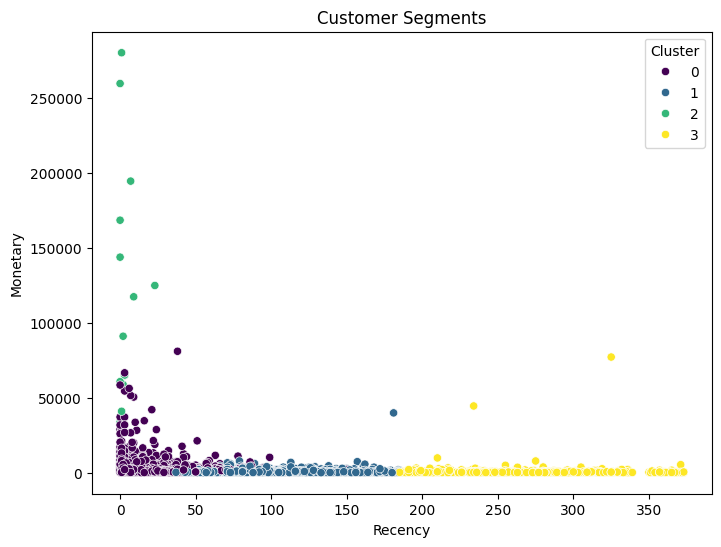

In [49]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=rfm['Recency'], y=rfm['Monetary'], hue=rfm['Cluster'], palette='viridis')
plt.title("Customer Segments")
plt.show()

In [51]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,19.886374,135.476212,2648.875746
1,96.846732,37.891811,777.692744
2,3.692308,2566.000000,126118.310000
3,271.196386,25.091566,604.752820


In [52]:
cluster_labels = {
    0: "Loyal Customers",
    1: "Regular Customers",
    2: "VIP Customers",
    3: "At Risk Customers"
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,325,1,77183.60,3,At Risk Customers
12347.0,1,182,4310.00,0,Loyal Customers
12348.0,74,31,1797.24,1,Regular Customers
12349.0,18,73,1757.55,0,Loyal Customers
12350.0,309,17,334.40,3,At Risk Customers


In [53]:
rfm['Segment'].value_counts()

Segment
Loyal Customers      2165
Regular Customers    1331
At Risk Customers     830
VIP Customers          13
Name: count, dtype: int64

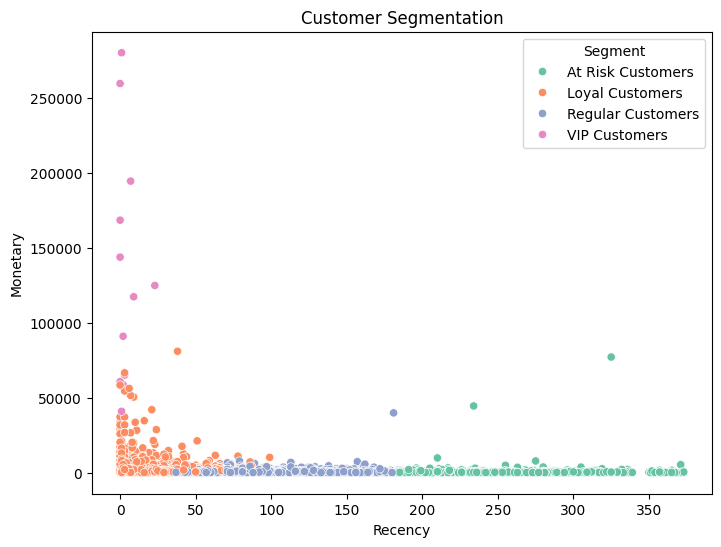

In [54]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=rfm['Recency'], y=rfm['Monetary'], hue=rfm['Segment'], palette='Set2')
plt.title("Customer Segmentation")
plt.show()

In [55]:
rfm['Segment'].value_counts()

Segment
Loyal Customers      2165
Regular Customers    1331
At Risk Customers     830
VIP Customers          13
Name: count, dtype: int64